In [1]:
!pip install prophet


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error



In [3]:
df = pd.read_csv("../Data/time_series_ready.csv")

df.head()

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,2009-12-01 07:45:00,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,2009-12-01 07:45:00,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,2009-12-01 07:45:00,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,2009-12-01 07:45:00,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,2009-12-01 07:45:00,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
daily_sales = (

    df.groupby("InvoiceDate")["TotalSales"]

      .sum()

      .reset_index()

)

In [6]:
daily_sales.columns = [

    "ds",

    "y"

]

daily_sales.head()

,ds,y
0,2009-12-01 07:45:00,404.50
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,613.33
3,2009-12-01 09:08:00,282.90
4,2009-12-01 09:28:00,356.40


In [7]:
model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=False

)

model.fit(daily_sales)

10:38:29 - cmdstanpy - INFO - Chain [1] start processing
10:38:34 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future_7 = model.make_future_dataframe(

    periods=7

)

forecast_7 = model.predict(future_7)

In [9]:
forecast_7[

    ["ds",

     "yhat",

     "yhat_lower",

     "yhat_upper"]

].tail(7)

,ds,yhat,yhat_lower,yhat_upper
31436,2011-12-10 12:50:00,215.765486,-117.043404,554.199980
31437,2011-12-11 12:50:00,249.601028,-64.097515,586.443192
31438,2011-12-12 12:50:00,274.198523,-58.963113,611.213764
31439,2011-12-13 12:50:00,260.432108,-52.659774,608.028342
31440,2011-12-14 12:50:00,256.103422,-89.275891,601.995498
31441,2011-12-15 12:50:00,256.321269,-69.418306,581.319417
31442,2011-12-16 12:50:00,252.083142,-73.707629,569.912400


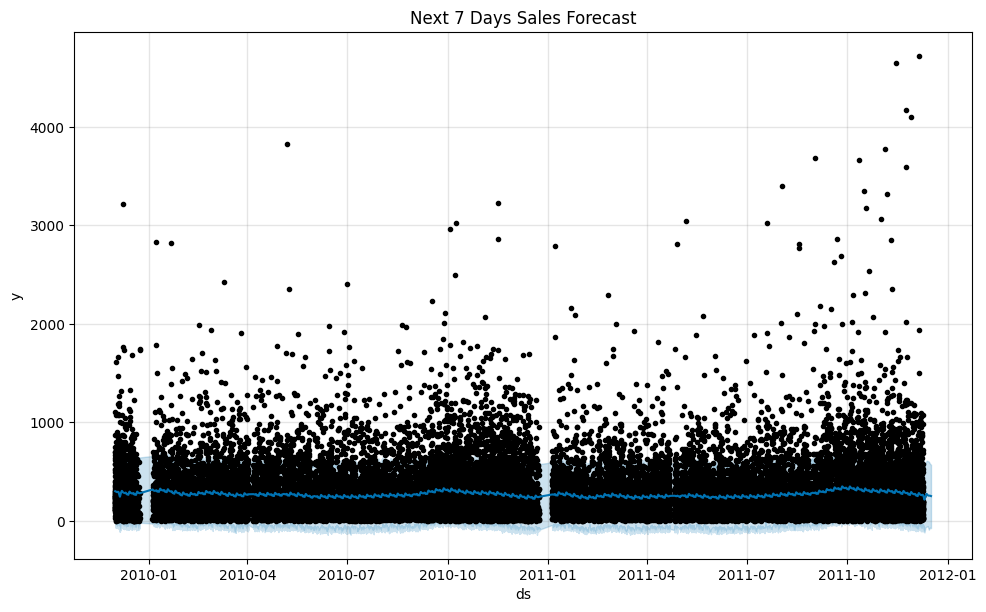

In [10]:
fig = model.plot(forecast_7)

plt.title("Next 7 Days Sales Forecast")

plt.show()

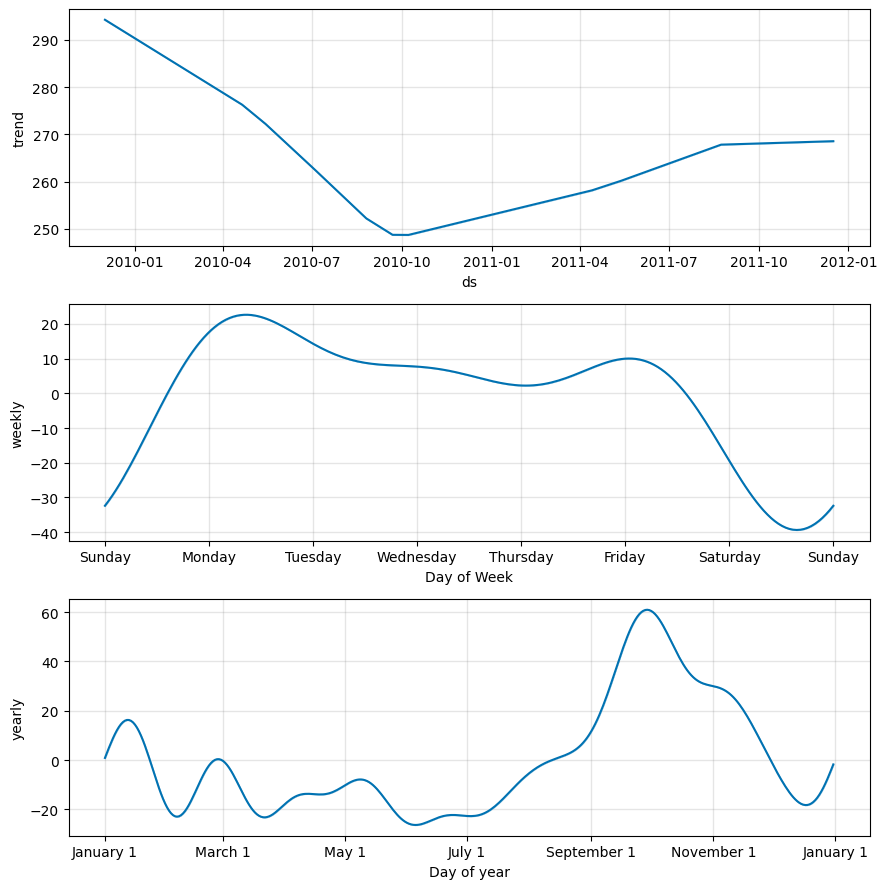

In [11]:
fig2 = model.plot_components(forecast_7)

plt.show()

In [12]:
future_30 = model.make_future_dataframe(

    periods=30

)

forecast_30 = model.predict(future_30)

In [13]:
forecast_30.tail(30)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
31436,2011-12-10 12:50:00,268.519147,-129.027954,544.857984,268.519147,268.519147,-52.753661,-52.753661,-52.753661,-38.597378,-38.597378,-38.597378,-14.156283,-14.156283,-14.156283,0.0,0.0,0.0,215.765486
31437,2011-12-11 12:50:00,268.525519,-66.012861,602.487254,268.525519,268.525519,-18.924490,-18.924490,-18.924490,-3.796953,-3.796953,-3.796953,-15.127537,-15.127537,-15.127537,0.0,0.0,0.0,249.601028
31438,2011-12-12 12:50:00,268.531890,-69.102760,588.240325,268.531890,268.531890,5.666633,5.666633,5.666633,21.656584,21.656584,21.656584,-15.989951,-15.989951,-15.989951,0.0,0.0,0.0,274.198523
31439,2011-12-13 12:50:00,268.538262,-91.831727,572.280720,268.538262,268.538262,-8.106154,-8.106154,-8.106154,8.625425,8.625425,8.625425,-16.731579,-16.731579,-16.731579,0.0,0.0,0.0,260.432108
31440,2011-12-14 12:50:00,268.544634,-71.458632,606.491114,268.544634,268.544634,-12.441212,-12.441212,-12.441212,4.899171,4.899171,4.899171,-17.340383,-17.340383,-17.340383,0.0,0.0,0.0,256.103422
31441,2011-12-15 12:50:00,268.551005,-75.372512,612.358721,268.549437,268.551005,-12.229737,-12.229737,-12.229737,5.574776,5.574776,5.574776,-17.804512,-17.804512,-17.804512,0.0,0.0,0.0,256.321269
31442,2011-12-16 12:50:00,268.557377,-102.089427,588.573189,268.548451,268.558576,-16.474236,-16.474236,-16.474236,1.638376,1.638376,1.638376,-18.112611,-18.112611,-18.112611,0.0,0.0,0.0,252.083142
31443,2011-12-17 12:50:00,268.563749,-119.247433,553.776848,268.547960,268.569697,-56.851537,-56.851537,-56.851537,-38.597378,-38.597378,-38.597378,-18.254159,-18.254159,-18.254159,0.0,0.0,0.0,211.712212
31444,2011-12-18 12:50:00,268.570120,-92.866876,612.707812,268.545953,268.579980,-22.016777,-22.016777,-22.016777,-3.796953,-3.796953,-3.796953,-18.219824,-18.219824,-18.219824,0.0,0.0,0.0,246.553344
31445,2011-12-19 12:50:00,268.576492,-60.681183,618.976102,268.541855,268.593645,3.654756,3.654756,3.654756,21.656584,21.656584,21.656584,-18.001827,-18.001827,-18.001827,0.0,0.0,0.0,272.231249


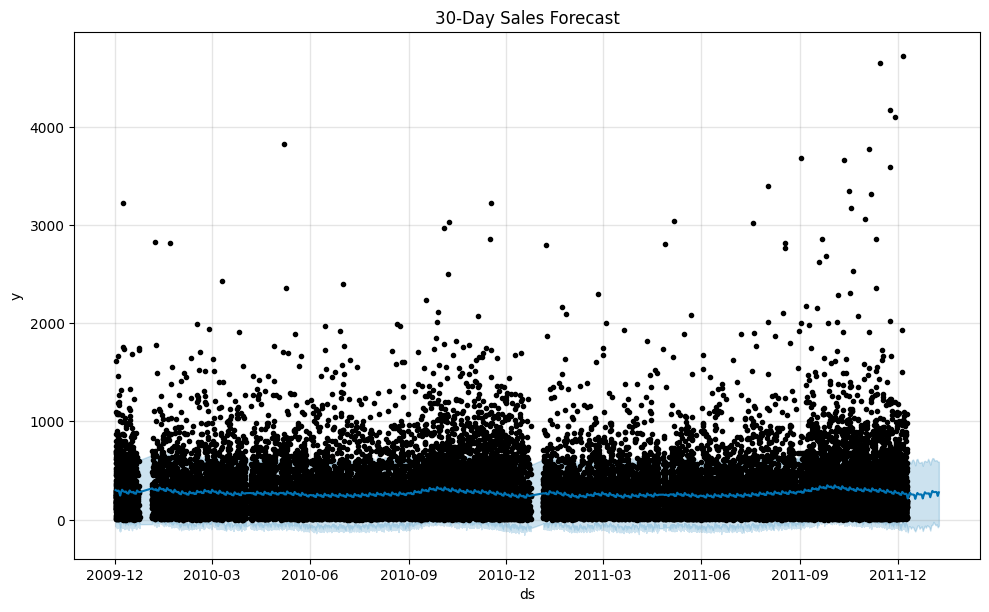

In [14]:
fig = model.plot(forecast_30)

plt.title("30-Day Sales Forecast")

plt.show()

In [15]:
forecast_30.to_csv(

    "prophet_forecast.csv",

    index=False

)

print("Forecast Saved")

Forecast Saved
